# Bayesian Optimization - Función 2

## Problema: Maximización de un score de log-likelihood con ruido en 2D

Optimización mediante:
- Gaussian Process (EI, UCB)
- HEBO
- criterio manual
- análisis de distancias y regiones prometedoras



## Política de dominio para iteración 

En esta iteración, todos los puntos propuestos deben respetar el dominio del portal:

- **0 es válido**
- **1 no es válido**

Por ello, el notebook usa el intervalo operativo **[0, 1)** y aplica validación/clipping a todos los candidatos generados por:

- GP + EI
- GP + UCB
- HEBO_GP_tuned
- HEBO_RF_tuned
- selección manual

Además, en esta iteración se incorpora una red neuronal para clasificación `high-performance vs low-performance` y un esquema de **meta-ranking** para seleccionar un único punto final.



## 1. Setup


In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

plt.rcParams["figure.figsize"] = (7, 5)
pd.set_option("display.precision", 6)
np.set_printoptions(suppress=False, precision=6)


## 2. Utilidades para localizar archivos y versionar datasets

Estas funciones permiten localizar automáticamente la versión más reciente del dataset y, en caso de agregar una observación manual, guardar una nueva versión sin sobrescribir la anterior.



In [2]:
def find_latest_version(base_name: str, ext: str = ".npy", folder: str = "."):
    """
    Busca la versión más reciente de un archivo con patrón:
    - base_name.npy
    - base_name_v2.npy
    - base_name_v3.npy
    ...

    Devuelve la ruta con la versión de mayor número.
    Si no hay versiones, devuelve la ruta del archivo base.
    """
    folder = Path(folder)
    candidates = list(folder.glob(f"{base_name}*{ext}"))

    if not candidates:
        return folder / f"{base_name}{ext}"

    def version_key(path: Path):
        stem = path.stem
        match = re.search(r"_v(\d+)$", stem)
        if match:
            return int(match.group(1))
        return 1 if stem == base_name else 0

    return max(candidates, key=version_key)



def next_version_path(path_like):
    """
    A partir de:
      archivo.npy    -> archivo_v2.npy
      archivo_v2.npy -> archivo_v3.npy
    """
    path = Path(path_like)
    stem = path.stem
    suffix = path.suffix

    match = re.search(r"^(.*)_v(\d+)$", stem)
    if match:
        base = match.group(1)
        version = int(match.group(2)) + 1
        return path.with_name(f"{base}_v{version}{suffix}")

    return path.with_name(f"{stem}_v2{suffix}")



def append_with_versioning(inputs_path, outputs_path, new_x, new_y):
    """
    Agrega una nueva observación al dataset y guarda una nueva versión
    sin sobrescribir los archivos existentes.

    Parámetros
    ----------
    inputs_path : str o Path
        Ruta al archivo .npy de inputs.
    outputs_path : str o Path
        Ruta al archivo .npy de outputs.
    new_x : array-like
        Nueva observación de entrada, por ejemplo [x1, x2].
    new_y : float
        Output asociado a new_x.
    """
    X = np.load(inputs_path)
    y = np.load(outputs_path)

    new_x = np.array(new_x, dtype=float).reshape(1, -1)
    new_y = float(new_y)

    if new_x.shape[1] != X.shape[1]:
        raise ValueError(
            f"Dimensión incorrecta: new_x tiene {new_x.shape[1]} columnas y X tiene {X.shape[1]}."
        )

    X_updated = np.vstack([X, new_x])
    y_updated = np.append(y, new_y)

    new_inputs_path = next_version_path(inputs_path)
    new_outputs_path = next_version_path(outputs_path)

    np.save(new_inputs_path, X_updated)
    np.save(new_outputs_path, y_updated)

    print("Se creó una nueva versión del dataset:")
    print("  Inputs :", new_inputs_path)
    print("  Outputs:", new_outputs_path)
    print("  Nuevo shape X:", X_updated.shape)
    print("  Nuevo shape y:", y_updated.shape)

    return Path(new_inputs_path), Path(new_outputs_path), X_updated, y_updated


## 3. Cargar la versión más reciente disponible


In [3]:
inputs_file = find_latest_version("2_initial_inputs")
outputs_file = find_latest_version("2_initial_outputs")

print("Archivo de inputs seleccionado :", inputs_file)
print("Archivo de outputs seleccionado:", outputs_file)

X = np.load(inputs_file)
y = np.load(outputs_file)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)


Archivo de inputs seleccionado : 2_initial_inputs_v12.npy
Archivo de outputs seleccionado: 2_initial_outputs_v12.npy

Shape X: (22, 2)
Shape y: (22,)


In [4]:
# Bounds operativos para el portal: dominio [0, 1)
EPS_BOUND = 1e-6
PORTAL_LB = 0.0
PORTAL_UB = 1.0 - EPS_BOUND

bounds = np.column_stack([
    np.full(X.shape[1], PORTAL_LB),
    np.full(X.shape[1], PORTAL_UB)
])

bounds_df = pd.DataFrame(bounds, columns=["lb", "ub"], index=[f"x{i+1}" for i in range(X.shape[1])])
display(bounds_df)

def clip_to_portal_bounds(point, lb=PORTAL_LB, ub=PORTAL_UB):
    point = np.asarray(point, dtype=float)
    return np.clip(point, lb, ub)

def validate_portal_bounds(point, lb=PORTAL_LB, ub=PORTAL_UB):
    point = np.asarray(point, dtype=float)
    return bool(np.all(point >= lb - 1e-15) and np.all(point < ub + 1e-15))

def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-12)


,lb,ub
x1,0.0,0.999999
x2,0.0,0.999999


## 4. Inspección del dataset


In [5]:
display(pd.DataFrame(X, columns=["x1", "x2"]).assign(y=y))

print("Resumen de y:")
print("  mínimo :", y.min())
print("  máximo :", y.max())
print("  media  :", y.mean())
print("  std    :", y.std())


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


Resumen de y:
  mínimo : -0.06562362443733738
  máximo : 0.6666540127898744
  media  : 0.29305729602937897
  std    : 0.25913776937777333


## 5. Actualización manual opcional del dataset

Cambia `DO_APPEND` a `True` solo cuando quieras registrar una nueva observación manual.



In [6]:
DO_APPEND = False

# Edita estos valores solo si DO_APPEND = True
NEW_X = [0.45, 0.67]
NEW_Y = 0.00123

if DO_APPEND:
    inputs_file, outputs_file, X, y = append_with_versioning(
        inputs_file, outputs_file, NEW_X, NEW_Y
    )
else:
    print("No se agregó ninguna observación nueva.")


No se agregó ninguna observación nueva.


## 6. Exportación opcional a Excel


In [7]:
EXPORT_TO_EXCEL = False
excel_name = "funcion_2_dataset.xlsx"

df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y

if EXPORT_TO_EXCEL:
    df.to_excel(excel_name, index=False)
    print(f"Archivo exportado: {excel_name}")
else:
    print("Exportación a Excel desactivada.")



Exportación a Excel desactivada.


## 7. Visualizaciones exploratorias


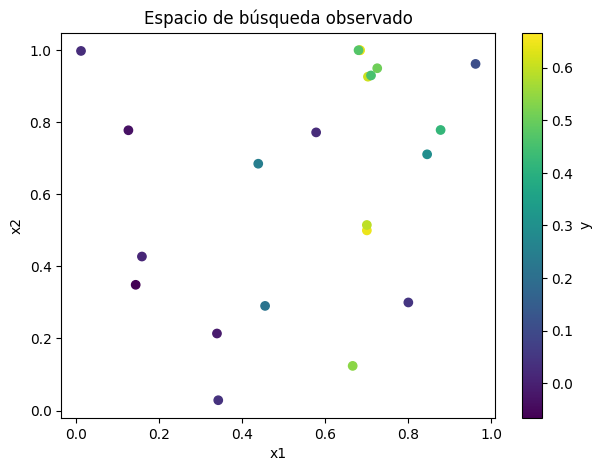

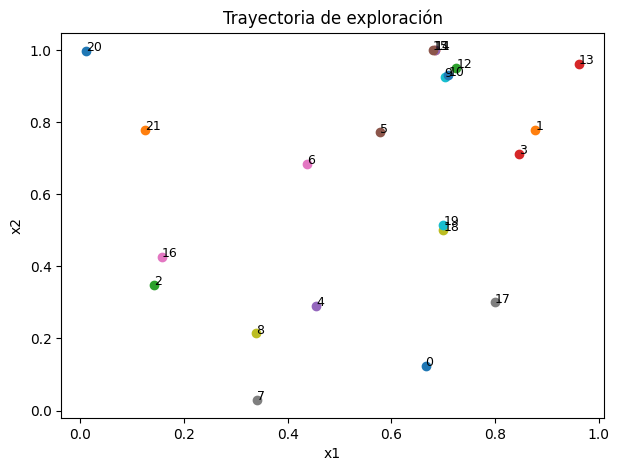

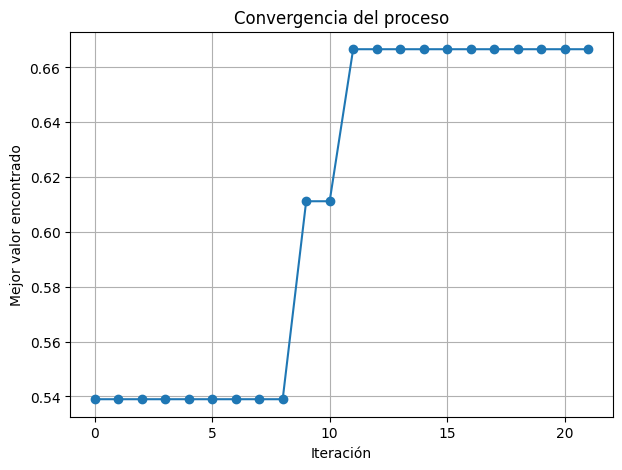

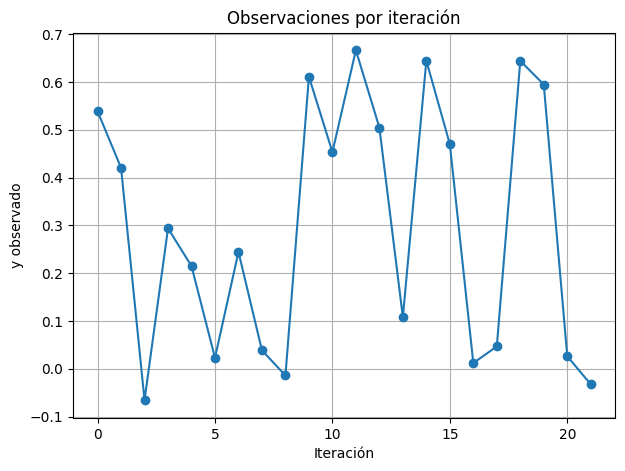

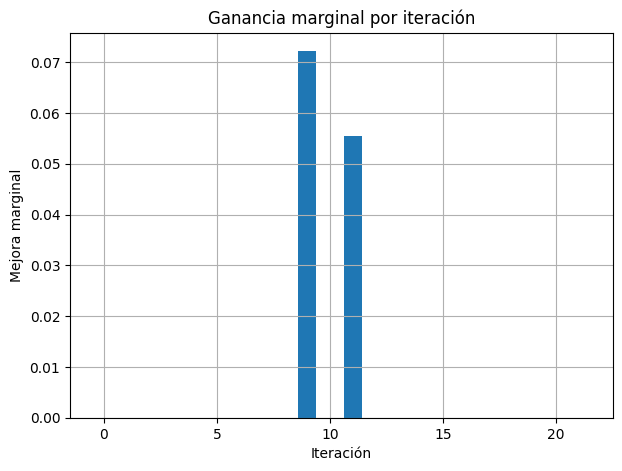

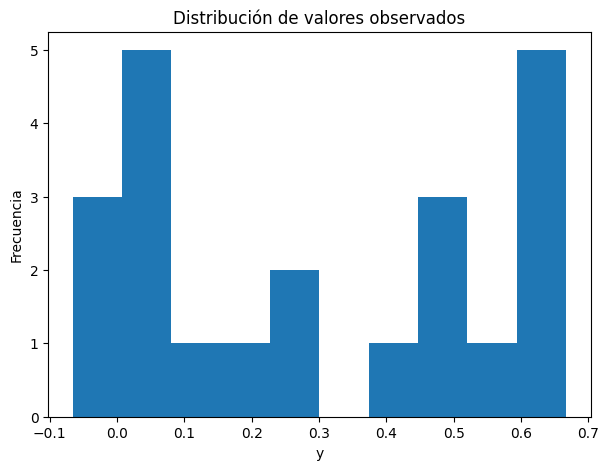

In [8]:
# 7.1 Espacio de búsqueda observado
plt.figure()
sc = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.colorbar(sc, label="y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Espacio de búsqueda observado")
plt.show()

# 7.2 Trayectoria de exploración
plt.figure()
for i in range(len(X)):
    plt.scatter(X[i, 0], X[i, 1])
    plt.text(X[i, 0], X[i, 1], str(i), fontsize=9)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Trayectoria de exploración")
plt.show()

# 7.3 Convergencia
best_so_far = np.maximum.accumulate(y)
plt.figure()
plt.plot(best_so_far, marker="o")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor encontrado")
plt.title("Convergencia del proceso")
plt.grid(True)
plt.show()

# 7.4 Observaciones por iteración
plt.figure()
plt.plot(y, marker="o")
plt.xlabel("Iteración")
plt.ylabel("y observado")
plt.title("Observaciones por iteración")
plt.grid(True)
plt.show()

# 7.5 Mejora marginal
improvement = np.diff(np.insert(best_so_far, 0, best_so_far[0]))
plt.figure()
plt.bar(range(len(improvement)), improvement)
plt.xlabel("Iteración")
plt.ylabel("Mejora marginal")
plt.title("Ganancia marginal por iteración")
plt.grid(True)
plt.show()

# 7.6 Distribución de outputs
plt.figure()
plt.hist(y, bins=min(10, len(y)))
plt.xlabel("y")
plt.ylabel("Frecuencia")
plt.title("Distribución de valores observados")
plt.show()


## 8. Definición del dominio operativo para GP / acquisition functions

Si no conoces los bounds reales, el notebook los infiere a partir de los datos observados y agrega un pequeño margen.
Si sí conoces los bounds verdaderos del problema, conviene fijarlos manualmente.



In [9]:
# Bounds operativos para el portal: valores estrictamente dentro de (0, 1)
EPS_BOUND = 1e-6
PORTAL_LB = 0.0 + EPS_BOUND
PORTAL_UB = 1.0 - EPS_BOUND

bounds = np.column_stack([
    np.full(X.shape[1], PORTAL_LB),
    np.full(X.shape[1], PORTAL_UB)
])

bounds_df = pd.DataFrame(bounds, columns=["lb", "ub"], index=[f"x{i+1}" for i in range(X.shape[1])])
display(bounds_df)

def clip_to_portal_bounds(point, lb=PORTAL_LB, ub=PORTAL_UB):
    point = np.asarray(point, dtype=float)
    return np.clip(point, lb, ub)

def validate_portal_bounds(point, lb=PORTAL_LB, ub=PORTAL_UB):
    point = np.asarray(point, dtype=float)
    return bool(np.all(point > lb - 1e-15) and np.all(point < ub + 1e-15))


,lb,ub
x1,0.000001,0.999999
x2,0.000001,0.999999


## 9. Ajuste del Gaussian Process


In [10]:
# WhiteKernel permite capturar algo de ruido si existe
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.2, 0.2], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42,
)

gp.fit(X, y)

print("Kernel ajustado:")
print(gp.kernel_)


Kernel ajustado:
0.882**2 * RBF(length_scale=[0.0538, 1e+03]) + WhiteKernel(noise_level=0.0593)


C:\Users\th3bl\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 10. Crear grid para predicción del GP


In [11]:
grid_size = 80

x1_lin = np.linspace(bounds[0, 0], bounds[0, 1], grid_size)
x2_lin = np.linspace(bounds[1, 0], bounds[1, 1], grid_size)

X1, X2 = np.meshgrid(x1_lin, x2_lin)
grid = np.c_[X1.ravel(), X2.ravel()]

mu, sigma = gp.predict(grid, return_std=True)

mu_grid = mu.reshape(X1.shape)
sigma_grid = sigma.reshape(X1.shape)


## 11. Visualización de la media posterior y la incertidumbre


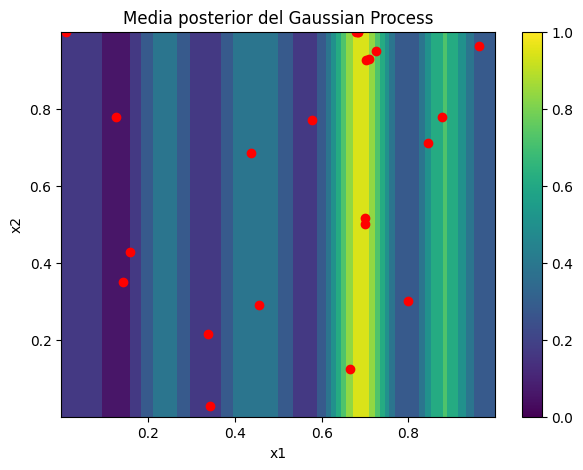

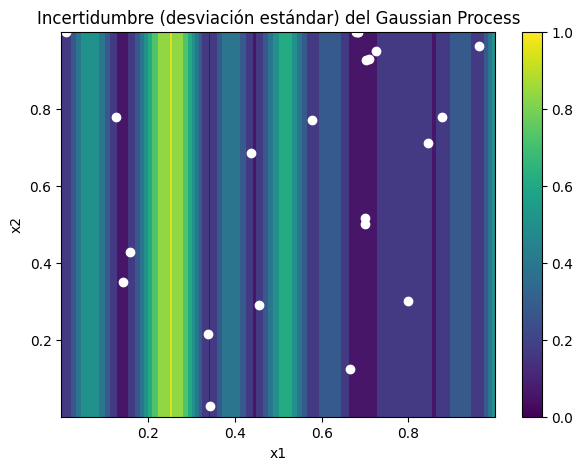

In [12]:
plt.figure()
plt.contourf(X1, X2, mu_grid)
plt.scatter(X[:, 0], X[:, 1], c="red")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Media posterior del Gaussian Process")
plt.colorbar()
plt.show()

plt.figure()
plt.contourf(X1, X2, sigma_grid)
plt.scatter(X[:, 0], X[:, 1], c="white")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Incertidumbre (desviación estándar) del Gaussian Process")
plt.colorbar()
plt.show()


## 12. Acquisition functions: EI y UCB


In [13]:
def expected_improvement(X_grid, gp_model, y_best, xi=0.01):
    mu_pred, sigma_pred = gp_model.predict(X_grid, return_std=True)
    sigma_pred = np.maximum(sigma_pred, 1e-12)

    improvement = mu_pred - y_best - xi
    Z = improvement / sigma_pred

    ei = improvement * norm.cdf(Z) + sigma_pred * norm.pdf(Z)
    ei[sigma_pred <= 1e-12] = 0.0
    return ei


def upper_confidence_bound(X_grid, gp_model, beta=2.0):
    mu_pred, sigma_pred = gp_model.predict(X_grid, return_std=True)
    return mu_pred + beta * sigma_pred


## 13. Visualización de EI y UCB


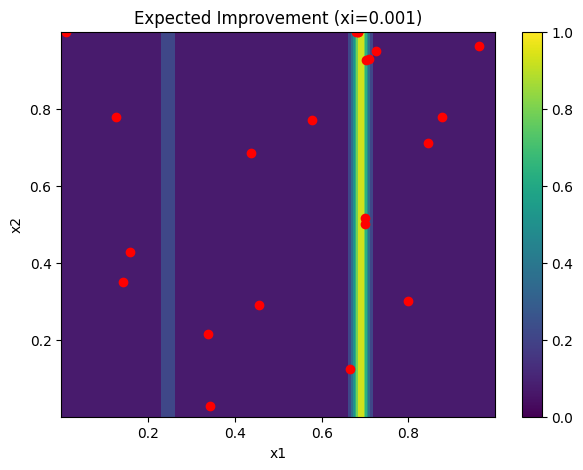

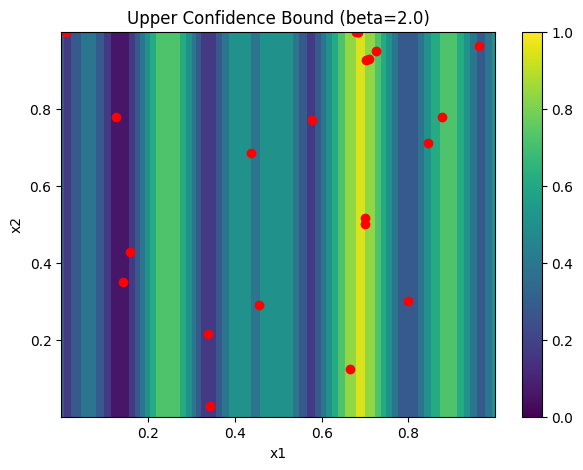

In [14]:
y_best = np.max(y)

EI_XI = 0.001
UCB_BETA = 2.0

ei = expected_improvement(grid, gp, y_best=y_best, xi=EI_XI)
ucb = upper_confidence_bound(grid, gp, beta=UCB_BETA)

ei_grid = ei.reshape(X1.shape)
ucb_grid = ucb.reshape(X1.shape)

plt.figure()
plt.contourf(X1, X2, ei_grid)
plt.scatter(X[:, 0], X[:, 1], c="red")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Expected Improvement (xi={EI_XI})")
plt.colorbar()
plt.show()

plt.figure()
plt.contourf(X1, X2, ucb_grid)
plt.scatter(X[:, 0], X[:, 1], c="red")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Upper Confidence Bound (beta={UCB_BETA})")
plt.colorbar()
plt.show()


## 14. Siguientes puntos sugeridos por GP + EI y GP + UCB


In [15]:
next_ei = clip_to_portal_bounds(grid[np.argmax(ei)])
next_ucb = clip_to_portal_bounds(grid[np.argmax(ucb)])

suggestions_df = pd.DataFrame({
    "metodo": ["GP + EI", "GP + UCB"],
    **{f"x{i+1}": [next_ei[i], next_ucb[i]] for i in range(X.shape[1])}
})

display(suggestions_df)


,metodo,x1,x2
0,GP + EI,0.696202,0.000001
1,GP + UCB,0.696202,0.000001


## 15. Visualización conjunta de sugerencias


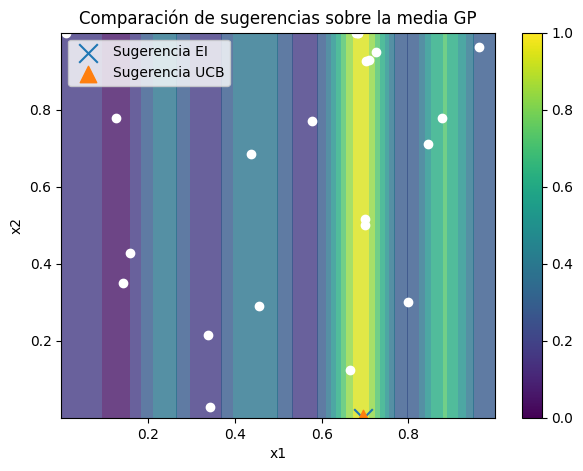

In [16]:
plt.figure()
plt.contourf(X1, X2, mu_grid, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c="white")
plt.scatter(next_ei[0], next_ei[1], marker="x", s=180, label="Sugerencia EI")
plt.scatter(next_ucb[0], next_ucb[1], marker="^", s=140, label="Sugerencia UCB")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Comparación de sugerencias sobre la media GP")
plt.legend()
plt.colorbar()
plt.show()


## 16. HEBO (opcional)

Esta sección intenta generar una sugerencia con HEBO.  
Si la librería no está instalada en tu entorno, el notebook seguirá funcionando sin esta parte.



## HEBO ajustado: dos variantes internas

En esta iteración se evalúan dos variantes de HEBO como generadores internos de candidatos:

1. **HEBO_GP_tuned**
2. **HEBO_RF_tuned**

La idea no es enviar más puntos al portal, sino usar más modelos para tomar una mejor decisión final.



In [17]:
hebo_gp_suggestion = None
hebo_rf_suggestion = None

try:
    from hebo.design_space.design_space import DesignSpace
    from hebo.optimizers.hebo import HEBO

    dim = X.shape[1]
    X_hebo = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(dim)])
    y_hebo = y.reshape(-1, 1)

    space = DesignSpace().parse([
        {"name": f"x{i+1}", "type": "num", "lb": float(bounds[i, 0]), "ub": float(bounds[i, 1])}
        for i in range(dim)
    ])

    opt_hebo_gp = HEBO(
        space,
        model_name="gp",
        rand_sample=max(12, 2 * dim),
        scramble_seed=42,
        model_config={
            "lr": 0.01,
            "num_epochs": 150,
            "verbose": False,
            "noise_lb": 1e-3,
            "pred_likeli": False,
        }
    )
    opt_hebo_gp.observe(X_hebo, y_hebo)
    rec_gp = opt_hebo_gp.suggest(n_suggestions=1)
    hebo_gp_suggestion = rec_gp.iloc[0].to_dict()
    hebo_gp_suggestion = {k: float(v) for k, v in hebo_gp_suggestion.items()}
    hebo_gp_suggestion = {k: float(clip_to_portal_bounds([v])[0]) for k, v in hebo_gp_suggestion.items()}

    opt_hebo_rf = HEBO(
        space,
        model_name="rf",
        rand_sample=max(12, 2 * dim),
        scramble_seed=42,
        model_config={"n_estimators": 50}
    )
    opt_hebo_rf.observe(X_hebo, y_hebo)
    rec_rf = opt_hebo_rf.suggest(n_suggestions=1)
    hebo_rf_suggestion = rec_rf.iloc[0].to_dict()
    hebo_rf_suggestion = {k: float(v) for k, v in hebo_rf_suggestion.items()}
    hebo_rf_suggestion = {k: float(clip_to_portal_bounds([v])[0]) for k, v in hebo_rf_suggestion.items()}

    hebo_variants_df = pd.DataFrame([
        {"metodo": "HEBO_GP_tuned", **hebo_gp_suggestion},
        {"metodo": "HEBO_RF_tuned", **hebo_rf_suggestion},
    ])
    display(hebo_variants_df)

except Exception as e:
    print("HEBO no disponible o no pudo ejecutarse.")
    print("Detalle:", e)


,metodo,x1,x2
0,HEBO_GP_tuned,0.120241,0.084776
1,HEBO_RF_tuned,0.612831,0.843671


## 17. Tabla consolidada de sugerencias


In [18]:
rows = [
    {"metodo": "GP + EI", **{f"x{i+1}": float(next_ei[i]) for i in range(X.shape[1])}},
    {"metodo": "GP + UCB", **{f"x{i+1}": float(next_ucb[i]) for i in range(X.shape[1])}},
]

if hebo_gp_suggestion is not None:
    rows.append({"metodo": "HEBO_GP_tuned", **{f"x{i+1}": float(hebo_gp_suggestion[f"x{i+1}"]) for i in range(X.shape[1])}})
if hebo_rf_suggestion is not None:
    rows.append({"metodo": "HEBO_RF_tuned", **{f"x{i+1}": float(hebo_rf_suggestion[f"x{i+1}"]) for i in range(X.shape[1])}})

comparison_df = pd.DataFrame(rows)
display(comparison_df)


,metodo,x1,x2
0,GP + EI,0.696202,0.000001
1,GP + UCB,0.696202,0.000001
2,HEBO_GP_tuned,0.120241,0.084776
3,HEBO_RF_tuned,0.612831,0.843671



## 18. Análisis de proximidad y distancias normalizadas

En esta sección se analiza qué tan cerca se encuentra cada punto candidato respecto a:

- la mejor observación actual,
- el conjunto completo de observaciones ya evaluadas,
- y sus vecinos más cercanos.

Además de la distancia euclidiana estándar, se incorporan **distancias normalizadas por rango** de cada variable. Esto será especialmente útil en funciones de mayor dimensionalidad o con escalas heterogéneas, ya que evita que una variable domine artificialmente la métrica de distancia.

### Interpretación general

- **Distancia pequeña al mejor punto**: sugiere explotación o refinamiento local.
- **Distancia grande al mejor punto**: sugiere exploración respecto a la mejor región conocida.
- **Distancia pequeña al dataset**: indica que el punto cae en una región ya observada.
- **Distancia grande al dataset**: indica novedad espacial y mayor componente exploratoria.
- **Vecinos cercanos con buen `y`**: favorecen una lectura de explotación local.
- **Vecinos cercanos con `y` muy bajos**: sugieren que el punto está en una región todavía poco prometedora o mal comprendida.

### Sobre la normalización

La distancia normalizada se calcula escalando cada variable por su rango operativo dentro del dataset (o por los bounds manuales si así se define más adelante). Esto permite que esta herramienta siga siendo útil cuando se analicen funciones de 4D, 6D u 8D.



In [19]:

# 18.1 Utilerías de distancia estándar y normalizada
def euclidean_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.linalg.norm(a - b)

def get_feature_ranges(X_array, bounds_override=None, eps=1e-12):
    X_array = np.asarray(X_array, dtype=float)

    if bounds_override is not None:
        lower = np.array([b[0] for b in bounds_override], dtype=float)
        upper = np.array([b[1] for b in bounds_override], dtype=float)
    else:
        lower = X_array.min(axis=0)
        upper = X_array.max(axis=0)

    ranges = np.maximum(upper - lower, eps)
    return lower, upper, ranges

def normalized_distance(a, b, ranges):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ranges = np.asarray(ranges, dtype=float)
    return np.linalg.norm((a - b) / ranges)

def distance_to_best(point, X_array, y_array, ranges=None):
    best_idx = int(np.argmax(y_array))
    best_point = X_array[best_idx]
    best_value = y_array[best_idx]

    result = {
        "best_index": best_idx,
        "best_value": float(best_value),
        "distance_to_best": euclidean_distance(point, best_point),
    }

    if ranges is not None:
        result["normalized_distance_to_best"] = normalized_distance(point, best_point, ranges)

    return result

def nearest_neighbors(point, X_array, y_array, k=3, ranges=None):
    point = np.asarray(point, dtype=float)
    X_array = np.asarray(X_array, dtype=float)
    y_array = np.asarray(y_array, dtype=float)

    distances = np.linalg.norm(X_array - point, axis=1)
    idx_sorted = np.argsort(distances)

    rows = []
    for idx in idx_sorted[:k]:
        row = {
            "neighbor_index": int(idx),
            "distance": float(distances[idx]),
            "y_neighbor": float(y_array[idx]),
        }

        if ranges is not None:
            row["normalized_distance"] = float(normalized_distance(point, X_array[idx], ranges))

        for j in range(X_array.shape[1]):
            row[f"x{j+1}_neighbor"] = float(X_array[idx, j])

        rows.append(row)

    return pd.DataFrame(rows)

def min_distance_to_dataset(point, X_array, ranges=None):
    point = np.asarray(point, dtype=float)
    X_array = np.asarray(X_array, dtype=float)

    distances = np.linalg.norm(X_array - point, axis=1)
    min_idx = int(np.argmin(distances))

    result = {
        "distance_to_nearest_observation": float(distances[min_idx]),
        "nearest_observation_index": min_idx
    }

    if ranges is not None:
        norm_distances = np.linalg.norm((X_array - point) / ranges, axis=1)
        result["normalized_distance_to_nearest_observation"] = float(norm_distances[min_idx])

    return result

def classify_candidate(point, X_array, y_array, ranges=None, quantile_threshold=0.5):
    point = np.asarray(point, dtype=float)
    X_array = np.asarray(X_array, dtype=float)

    distances = np.linalg.norm(X_array - point, axis=1)
    threshold = float(np.quantile(distances, quantile_threshold))
    min_dist = float(np.min(distances))

    zone_type = "Exploración" if min_dist > threshold else "Explotación / refinamiento local"

    result = {
        "distance_threshold_reference": threshold,
        "zone_type": zone_type
    }

    if ranges is not None:
        norm_distances = np.linalg.norm((X_array - point) / ranges, axis=1)
        result["normalized_distance_threshold_reference"] = float(np.quantile(norm_distances, quantile_threshold))
        result["min_normalized_distance_to_dataset"] = float(np.min(norm_distances))

    return result

# usar bounds manuales si existen; en caso contrario, usar rango observado
try:
    if USE_MANUAL_BOUNDS:
        bounds_for_distance = bounds
    else:
        bounds_for_distance = None
except NameError:
    bounds_for_distance = None

lower_d, upper_d, ranges_d = get_feature_ranges(X, bounds_override=bounds_for_distance)

feature_ranges_df = pd.DataFrame({
    "feature": [f"x{i+1}" for i in range(X.shape[1])],
    "lower": lower_d,
    "upper": upper_d,
    "range": ranges_d
})

display(feature_ranges_df)


,feature,lower,upper,range
0,x1,0.010879,0.962024,0.951145
1,x2,0.028698,0.999999,0.971301


In [20]:
# Construir tabla de candidatos desde la tabla consolidada de sugerencias
candidates = comparison_df.copy()
candidates = candidates.rename(columns={"metodo": "method"})
display(candidates)


,method,x1,x2
0,GP + EI,0.696202,0.000001
1,GP + UCB,0.696202,0.000001
2,HEBO_GP_tuned,0.120241,0.084776
3,HEBO_RF_tuned,0.612831,0.843671


In [21]:
# Resumen de distancias para cada candidato
distance_rows = []
feature_cols = [col for col in candidates.columns if col.startswith("x")]

for _, row in candidates.iterrows():
    point = row[feature_cols].to_numpy(dtype=float)

    info_best = distance_to_best(point, X, y, ranges=ranges_d)
    info_dataset = min_distance_to_dataset(point, X, ranges=ranges_d)
    info_class = classify_candidate(point, X, y, ranges=ranges_d, quantile_threshold=0.5)

    distance_rows.append({
        "method": row["method"],
        "distance_to_best": info_best["distance_to_best"],
        "normalized_distance_to_best": info_best.get("normalized_distance_to_best", np.nan),
        "distance_to_nearest_observation": info_dataset["distance_to_nearest_observation"],
        "normalized_distance_to_nearest_observation": info_dataset.get("normalized_distance_to_nearest_observation", np.nan),
        "nearest_observation_index": info_dataset["nearest_observation_index"],
        "best_observation_index": info_best["best_index"],
        "best_observation_value": info_best["best_value"],
        "distance_threshold_reference": info_class["distance_threshold_reference"],
        "normalized_distance_threshold_reference": info_class.get("normalized_distance_threshold_reference", np.nan),
        "zone_type": info_class["zone_type"]
    })

distance_summary = pd.DataFrame(distance_rows)
display(distance_summary.sort_values("method"))


,method,distance_to_best,normalized_distance_to_best,distance_to_nearest_observation,normalized_distance_to_nearest_observation,nearest_observation_index,best_observation_index,best_observation_value,distance_threshold_reference,normalized_distance_threshold_reference,zone_type
0,GP + EI,1.000077,1.029630,0.127642,0.131573,0,11,0.666654,0.756509,0.780061,Explotación / refinamiento local
1,GP + UCB,1.000077,1.029630,0.127642,0.131573,0,11,0.666654,0.756509,0.780061,Explotación / refinamiento local
2,HEBO_GP_tuned,1.074561,1.112797,0.228497,0.239936,7,11,0.666654,0.773747,0.804492,Explotación / refinamiento local
3,HEBO_RF_tuned,0.171480,0.177185,0.079837,0.082535,5,11,0.666654,0.347294,0.358038,Explotación / refinamiento local


In [22]:
# Vecinos más cercanos de cada candidato
K_NEIGHBORS = 3
feature_cols = [col for col in candidates.columns if col.startswith("x")]

for _, row in candidates.iterrows():
    method = row["method"]
    point = row[feature_cols].to_numpy(dtype=float)

    print("\n" + "="*80)
    print(f"Método: {method}")
    print(f"Punto candidato: {point}")

    nn_df = nearest_neighbors(point, X, y, k=K_NEIGHBORS, ranges=ranges_d)
    display(nn_df)



Método: GP + EI
Punto candidato: [6.962021e-01 1.000000e-06]


,neighbor_index,distance,y_neighbor,normalized_distance,x1_neighbor,x2_neighbor
0,0,0.127642,0.538996,0.131573,0.66580,0.123969
1,17,0.317448,0.046899,0.327575,0.80000,0.300000
2,7,0.355612,0.038749,0.373828,0.34175,0.028698



Método: GP + UCB
Punto candidato: [6.962021e-01 1.000000e-06]


,neighbor_index,distance,y_neighbor,normalized_distance,x1_neighbor,x2_neighbor
0,0,0.127642,0.538996,0.131573,0.66580,0.123969
1,17,0.317448,0.046899,0.327575,0.80000,0.300000
2,7,0.355612,0.038749,0.373828,0.34175,0.028698



Método: HEBO_GP_tuned
Punto candidato: [0.120241 0.084776]


,neighbor_index,distance,y_neighbor,normalized_distance,x1_neighbor,x2_neighbor
0,7,0.228497,0.038749,0.239936,0.341750,0.028698
1,8,0.253705,-0.013858,0.265314,0.338648,0.213867
2,2,0.265182,-0.065624,0.273059,0.142699,0.349005



Método: HEBO_RF_tuned
Punto candidato: [0.612831 0.843671]


,neighbor_index,distance,y_neighbor,normalized_distance,x1_neighbor,x2_neighbor
0,5,0.079837,0.023106,0.082535,0.577713,0.771973
1,9,0.122214,0.611205,0.127272,0.702637,0.926564
2,10,0.129979,0.453543,0.135412,0.710000,0.930000


In [23]:

# 18.5 Distancia del mejor punto actual a sus vecinos más cercanos
best_idx = int(np.argmax(y))
best_point = X[best_idx]
best_value = y[best_idx]

print(f"Mejor observación actual -> índice: {best_idx}, punto: {best_point}, y: {best_value:.6e}")

dist_to_best = np.linalg.norm(X - best_point, axis=1)
order = np.argsort(dist_to_best)

best_neighbors_rows = []
for idx in order[1:1+K_NEIGHBORS]:
    row = {
        "neighbor_index": int(idx),
        "distance_to_best_point": float(dist_to_best[idx]),
        "normalized_distance_to_best_point": float(normalized_distance(best_point, X[idx], ranges_d)),
        "y_neighbor": float(y[idx]),
    }
    for j in range(X.shape[1]):
        row[f"x{j+1}_neighbor"] = float(X[idx, j])
    best_neighbors_rows.append(row)

best_neighbors_df = pd.DataFrame(best_neighbors_rows)
display(best_neighbors_df)


Mejor observación actual -> índice: 11, punto: [0.683317 0.999995], y: 6.666540e-01


,neighbor_index,distance_to_best_point,normalized_distance_to_best_point,y_neighbor,x1_neighbor,x2_neighbor
0,14,0.000227,0.000239,0.644710,0.683544,0.999999
1,15,0.003317,0.003487,0.470301,0.680000,0.999995
2,12,0.065092,0.067601,0.504771,0.725000,0.950000


## 22. Clasificación de regiones high vs low con SVM

Como herramienta complementaria para la iteración 4, se incorpora un modelo SVM para clasificar observaciones en:

- **high-performance**
- **low-performance**

La idea no es reemplazar Bayesian Optimization, sino obtener una señal adicional sobre si el dataset ya sugiere una región separable de alto desempeño.

Se entrenan dos variantes:

1. **Soft-margin linear SVM**
2. **Kernel SVM (RBF)**

La etiqueta binaria se define usando un umbral sobre `y`. Por defecto, se marca como **high-performance** el cuantil superior del 30% de observaciones.



In [28]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score

HIGH_Q = 0.70
y_threshold = np.quantile(y, HIGH_Q)
y_binary = (y >= y_threshold).astype(int)

label_df = pd.DataFrame({
    "y": y,
    "label_high": y_binary
})
print("Umbral para clase high:", y_threshold)
display(label_df.head())
print("Distribución de clases:")
print(pd.Series(y_binary).value_counts().sort_index())


Umbral para clase high: 0.49442985684817686


,y,label_high
0,0.538996,1
1,0.420586,0
2,-0.065624,0
3,0.293993,0
4,0.214965,0


Distribución de clases:
0    15
1     7
Name: count, dtype: int64


In [29]:
linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, class_weight="balanced"))
])

rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"))
])

linear_svm.fit(X, y_binary)
rbf_svm.fit(X, y_binary)

pred_linear = linear_svm.predict(X)
pred_rbf = rbf_svm.predict(X)

svm_eval_df = pd.DataFrame({
    "modelo": ["Linear SVM", "RBF SVM"],
    "train_accuracy": [
        accuracy_score(y_binary, pred_linear),
        accuracy_score(y_binary, pred_rbf)
    ]
})
display(svm_eval_df)

print("Confusion matrix - Linear SVM")
print(confusion_matrix(y_binary, pred_linear))

print("Confusion matrix - RBF SVM")
print(confusion_matrix(y_binary, pred_rbf))


,modelo,train_accuracy
0,Linear SVM,0.681818
1,RBF SVM,0.727273


Confusion matrix - Linear SVM
[[8 7]
 [0 7]]
Confusion matrix - RBF SVM
[[9 6]
 [0 7]]


In [30]:
candidate_scores = comparison_df.copy()
candidate_X = candidate_scores[[c for c in candidate_scores.columns if c.startswith("x")]].values.astype(float)

candidate_scores["linear_svm_score"] = linear_svm.decision_function(candidate_X)
candidate_scores["rbf_svm_score"] = rbf_svm.decision_function(candidate_X)
candidate_scores["linear_svm_pred_high"] = linear_svm.predict(candidate_X)
candidate_scores["rbf_svm_pred_high"] = rbf_svm.predict(candidate_X)

display(candidate_scores)


,metodo,x1,x2,linear_svm_score,rbf_svm_score,linear_svm_pred_high,rbf_svm_pred_high
0,GP + EI,0.696202,0.000001,0.597143,0.590746,1,1
1,GP + UCB,0.696202,0.000001,0.597143,0.590746,1,1
2,HEBO_GP_tuned,0.120241,0.084776,-1.980543,-1.071911,0,0
3,HEBO_RF_tuned,0.612831,0.843671,0.606767,0.867863,1,1


## 23. Interpretación de SVM

- Si **Linear SVM** y **RBF SVM** clasifican una sugerencia como `high-performance`, eso refuerza la idea de que el punto cae dentro de una región prometedora.
- Si **RBF SVM** detecta una región high-performance pero **Linear SVM** no, eso sugiere una frontera **no lineal**.
- Si ambos clasifican una sugerencia como `low-performance`, puede ser una señal de alerta adicional.

En superficies no lineales, un **kernel SVM** suele ser más útil que un SVM lineal, porque puede modelar fronteras curvas entre regiones de alto y bajo desempeño.



## 24. Clasificación de regiones high vs low con red neuronal

Como complemento a SVM, se entrena una red neuronal pequeña (MLP) para clasificar observaciones en regiones de:

- **high-performance**
- **low-performance**

La red neuronal permite capturar fronteras no lineales y aportar una segunda opinión estructural sobre los candidatos.



In [31]:
from sklearn.neural_network import MLPClassifier

nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        max_iter=500,
        random_state=42
    ))
])

nn_model.fit(X, y_binary)

pred_nn = nn_model.predict(X)
nn_train_acc = accuracy_score(y_binary, pred_nn)

nn_eval_df = pd.DataFrame({
    "modelo": ["Neural Network (MLP)"],
    "train_accuracy": [nn_train_acc]
})
display(nn_eval_df)

print("Confusion matrix - Neural Network")
print(confusion_matrix(y_binary, pred_nn))


,modelo,train_accuracy
0,Neural Network (MLP),0.909091


Confusion matrix - Neural Network
[[13  2]
 [ 0  7]]


In [32]:
candidate_scores = comparison_df.copy()
candidate_X = candidate_scores[[c for c in candidate_scores.columns if c.startswith("x")]].values.astype(float)

candidate_scores["linear_svm_score"] = linear_svm.decision_function(candidate_X)
candidate_scores["rbf_svm_score"] = rbf_svm.decision_function(candidate_X)
candidate_scores["linear_svm_pred_high"] = linear_svm.predict(candidate_X)
candidate_scores["rbf_svm_pred_high"] = rbf_svm.predict(candidate_X)

candidate_scores["nn_prob_high"] = nn_model.predict_proba(candidate_X)[:, 1]
candidate_scores["nn_pred_high"] = nn_model.predict(candidate_X)

display(candidate_scores)


,metodo,x1,x2,linear_svm_score,rbf_svm_score,linear_svm_pred_high,rbf_svm_pred_high,nn_prob_high,nn_pred_high
0,GP + EI,0.696202,0.000001,0.597143,0.590746,1,1,8.920272e-01,1
1,GP + UCB,0.696202,0.000001,0.597143,0.590746,1,1,8.920272e-01,1
2,HEBO_GP_tuned,0.120241,0.084776,-1.980543,-1.071911,0,0,2.088058e-07,0
3,HEBO_RF_tuned,0.612831,0.843671,0.606767,0.867863,1,1,1.470717e-01,0


## 19. Decisión manual final

Usa esta sección como bitácora analítica para registrar tu criterio final.

**Puntos a considerar:**
- ¿EI sugiere explotar una región prometedora?
- ¿UCB sugiere explorar una zona poco conocida?
- ¿HEBO coincide con alguna de las anteriores o propone algo distinto?
- ¿El mejor valor actual justifica explotación local?
- ¿La distribución espacial de los puntos sugiere que todavía falta cobertura del dominio?

### Registro de decisión
- **Punto elegido manualmente:**
- **Motivo principal de la elección:**
- **Método que más influyó en la decisión:**
- **Comentario sobre exploración vs explotación:**
- **Plan para la siguiente iteración:**



## 20. Diagnóstico de clusters de zonas prometedoras

En esta sección se busca identificar si los puntos con mejor desempeño comienzan a formar **agrupaciones locales**.

La idea es útil porque, en funciones complejas, no basta con conocer el mejor punto aislado: también interesa saber si existe una **zona prometedora** con varios vecinos razonablemente buenos.

### Objetivo del análisis
Se evalúa si los puntos con mayor `y`:

- aparecen **aislados**, lo que sugiere un comportamiento más **spiky**,
- o bien empiezan a formar **clusters locales**, lo que sugiere que podría ser razonable iniciar una fase de explotación local.

### Qué se analiza
1. **Top-k mejores observaciones**
2. **Clusters por cercanía espacial**
3. **Calidad de cada cluster**
4. **Interpretación estratégica**

> En funciones de mayor dimensión, este bloque será especialmente valioso porque reemplaza parte de la intuición visual que se pierde al no poder graficar el espacio completo.



In [33]:
# 20.1 Utilerías para clusters de zonas prometedoras
import numpy as np
import pandas as pd

def get_variable_ranges(X):
    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1.0
    return mins, maxs, ranges

def pairwise_normalized_distances(X):
    _, _, ranges = get_variable_ranges(X)
    Xn = X / ranges
    diff = Xn[:, None, :] - Xn[None, :, :]
    D = np.sqrt(np.sum(diff**2, axis=2))
    return D

def connected_components_from_adjacency(adj):
    n = adj.shape[0]
    visited = np.zeros(n, dtype=bool)
    components = []

    for i in range(n):
        if not visited[i]:
            stack = [i]
            visited[i] = True
            comp = []

            while stack:
                node = stack.pop()
                comp.append(node)
                neighbors = np.where(adj[node])[0]
                for nb in neighbors:
                    if not visited[nb]:
                        visited[nb] = True
                        stack.append(nb)

            components.append(sorted(comp))
    return components

def detect_promising_clusters(
    X, y,
    top_k=None,
    y_quantile=0.75,
    distance_quantile=0.25,
    min_cluster_size=2
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    if top_k is not None:
        idx_top = np.argsort(y)[-top_k:]
    else:
        thr = np.quantile(y, y_quantile)
        idx_top = np.where(y >= thr)[0]

    idx_top = np.array(sorted(idx_top))
    X_top = X[idx_top]
    y_top = y[idx_top]

    if len(idx_top) == 0:
        return pd.DataFrame(), [], idx_top, None

    D = pairwise_normalized_distances(X_top)

    if len(idx_top) > 1:
        off_diag = D[np.triu_indices_from(D, k=1)]
        eps = np.quantile(off_diag, distance_quantile)
        adj = (D <= eps)
        np.fill_diagonal(adj, True)
        components = connected_components_from_adjacency(adj)
    else:
        eps = None
        components = [[0]]

    best_global_idx = int(np.argmax(y))
    best_global_point = X[best_global_idx]

    rows = []
    valid_clusters = []

    for cid, comp_local in enumerate(components):
        global_indices = idx_top[comp_local]
        cluster_X = X[global_indices]
        cluster_y = y[global_indices]

        centroid = cluster_X.mean(axis=0)
        _, _, ranges = get_variable_ranges(X)
        centroid_norm = centroid / ranges
        cluster_norm = cluster_X / ranges
        dispersion = np.mean(np.sqrt(np.sum((cluster_norm - centroid_norm)**2, axis=1)))
        dist_to_best = np.linalg.norm((centroid - best_global_point) / ranges)

        row = {
            "cluster_id": cid,
            "n_points": len(global_indices),
            "global_indices": list(map(int, global_indices)),
            "best_y_in_cluster": float(np.max(cluster_y)),
            "mean_y_in_cluster": float(np.mean(cluster_y)),
            "median_y_in_cluster": float(np.median(cluster_y)),
            "centroid_distance_to_best": float(dist_to_best),
            "normalized_dispersion": float(dispersion),
        }

        for j in range(X.shape[1]):
            row[f"centroid_x{j+1}"] = float(centroid[j])

        rows.append(row)

        if len(global_indices) >= min_cluster_size:
            valid_clusters.append((cid, global_indices))

    summary = pd.DataFrame(rows).sort_values(
        by=["best_y_in_cluster", "n_points"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return summary, valid_clusters, idx_top, eps


In [34]:
# 20.2 Ejecutar diagnóstico de clusters prometedores
top_k_for_clusters = min(5, len(y))
cluster_summary, valid_clusters, idx_top_for_clusters, cluster_eps = detect_promising_clusters(
    X, y,
    top_k=top_k_for_clusters,
    distance_quantile=0.35,
    min_cluster_size=2
)

print("Índices top-k considerados:", idx_top_for_clusters)
print("Umbral de conexión normalizado (eps):", cluster_eps)

if len(cluster_summary) > 0:
    display(cluster_summary)
else:
    display(pd.DataFrame({"mensaje": ["No se detectaron puntos suficientes para clusterizar."]}))


Índices top-k considerados: [ 9 11 14 18 19]
Umbral de conexión normalizado (eps): 0.8842456039250297


,cluster_id,n_points,global_indices,best_y_in_cluster,mean_y_in_cluster,median_y_in_cluster,centroid_distance_to_best,normalized_dispersion,centroid_x1,centroid_x2
0,1,2,"[11, 14]",0.666654,0.655682,0.655682,0.000119,0.000119,0.683431,0.999997
1,0,3,"[9, 18, 19]",0.644495,0.616855,0.611205,0.363700,0.191758,0.700879,0.647188


In [35]:
# 20.3 Interpretación automática de clusters
def interpret_cluster_structure(cluster_summary, valid_clusters):
    if cluster_summary is None or len(cluster_summary) == 0:
        return {
            "cluster_diagnosis": "inconclusive",
            "strategy_note": "No hay suficientes puntos altos para identificar clusters prometedores."
        }

    if len(valid_clusters) == 0:
        return {
            "cluster_diagnosis": "isolated_high_points",
            "strategy_note": (
                "Los puntos de alto valor aparecen aislados. "
                "Esto favorece una estrategia de exploración continua."
            )
        }

    best_cluster = cluster_summary.iloc[0]

    if best_cluster["n_points"] >= 2 and best_cluster["normalized_dispersion"] < 0.20:
        return {
            "cluster_diagnosis": "promising_local_region",
            "strategy_note": (
                "Existe al menos un cluster compacto de puntos relativamente altos. "
                "Puede empezar a considerarse explotación local controlada."
            )
        }

    return {
        "cluster_diagnosis": "weak_or_diffuse_clusters",
        "strategy_note": (
            "Hay agrupaciones débiles o difusas, pero aún no una región claramente consolidada. "
            "Conviene mantener exploración moderada/alta."
        )
    }

cluster_diagnosis = interpret_cluster_structure(cluster_summary, valid_clusters)
print("Diagnóstico de clusters:", cluster_diagnosis["cluster_diagnosis"])
print("Recomendación estratégica:", cluster_diagnosis["strategy_note"])


Diagnóstico de clusters: promising_local_region
Recomendación estratégica: Existe al menos un cluster compacto de puntos relativamente altos. Puede empezar a considerarse explotación local controlada.


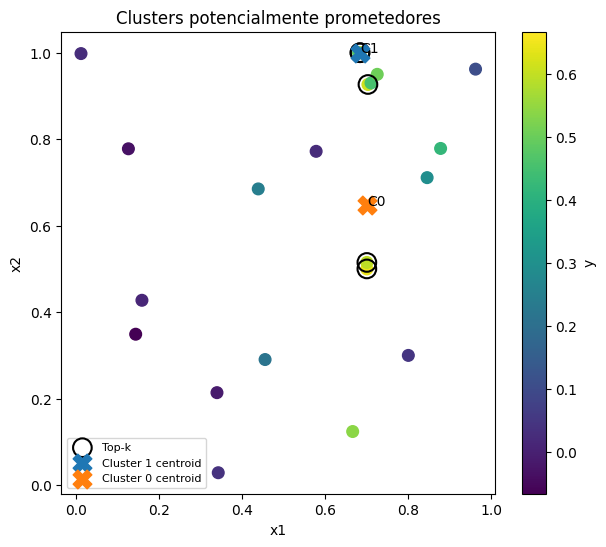

In [36]:
# 20.4 Visualización de clusters (solo para funciones 2D)
if X.shape[1] == 2:
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=70)
    plt.colorbar(sc, label="y")

    top_k_idx = np.argsort(y)[-top_k_for_clusters:]
    plt.scatter(
        X[top_k_idx, 0], X[top_k_idx, 1],
        facecolors='none', edgecolors='black',
        s=180, linewidths=1.5, label='Top-k'
    )

    if len(cluster_summary) > 0:
        centroid_cols = [c for c in cluster_summary.columns if c.startswith("centroid_x")]
        for _, row in cluster_summary.iterrows():
            cx = row[centroid_cols[0]]
            cy = row[centroid_cols[1]]
            plt.scatter(cx, cy, marker='X', s=180, label=f'Cluster {int(row["cluster_id"])} centroid')
            plt.text(cx, cy, f'C{int(row["cluster_id"])}', fontsize=10)

    plt.title("Clusters potencialmente prometedores")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend(loc="best", fontsize=8)
    plt.show()
else:
    print("La visualización de clusters se omite porque la función no es 2D.")


## 21. Uso estratégico del diagnóstico de clusters

El diagnóstico de clusters puede complementar la decisión entre GP, UCB y HEBO de la siguiente forma:

- **Si no hay clusters claros** → favorecer exploración.
- **Si hay un cluster compacto con varios puntos altos** → considerar explotación local controlada.
- **Si hay clusters débiles o difusos** → combinar exploración con refinamiento prudente.

Este bloque será especialmente útil en funciones de mayor dimensión, donde la geometría local de los mejores puntos no puede inspeccionarse visualmente con facilidad.

